# LoRA Hyperparameter Sensitivity Analysis – Google Colab

Identifies which LoRA hyperparameters (`lora_r`, `lora_alpha`, `lora_dropout`, `learning_rate`, `use_ffn`)
have the largest impact on fine-tuning performance of the pretrained **NeoQuasar/Kronos-base** model.

**Workflow:**
1. Setup environment
2. Prepare training data (arrow format)
3. Random search: sample LoRA configs → brief fine-tune → evaluate
4. Random Forest analysis to rank parameter importance
5. Download results

## Setup: Clone Repository

In [1]:
!rm -rf /content/BA
print("Cleaned up.")

Cleaned up.


In [2]:
import os
from pathlib import Path

repo_url = "https://github.com/bp571/BA"

%cd /content
!git clone {repo_url}
%cd /content/BA

# Tiingo API key
TIINGO_API_KEY = "312c6dab6a1fe6258bbc6652bcdec49a14ee08ad"
os.environ["TIINGO_API_KEY"] = TIINGO_API_KEY
Path(".env").write_text(f"TIINGO_API_KEY={TIINGO_API_KEY}\n")
print("✅ API key configured")

# Clone Kronos (gitignored in main repo)
!git clone https://github.com/shiyu-coder/Kronos.git 02_finetuning/models/Kronos
print("✅ Kronos cloned")

/content
Cloning into 'BA'...
remote: Enumerating objects: 592, done.
remote: Counting objects: 100% (63/63), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 592 (delta 31), reused 48 (delta 21), pack-reused 529 (from 1)
Receiving objects: 100% (592/592), 13.43 MiB | 32.22 MiB/s, done.
Resolving deltas: 100% (267/267), done.
/content/BA
✅ API key configured
Cloning into '02_finetuning/models/Kronos'...
remote: Enumerating objects: 371, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 371 (delta 6), reused 4 (delta 4), pack-reused 360 (from 2)
Receiving objects: 100% (371/371), 9.32 MiB | 33.02 MiB/s, done.
Resolving deltas: 100% (174/174), done.
✅ Kronos cloned


## Install Dependencies

In [3]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn tqdm einops \
    peft transformers huggingface_hub \
    gluonts python-dotenv tiingo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 42.9 MB/s eta 0:00:0000:01


In [4]:
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


## Prepare Training Data

`.arrow` files are gitignored and must be generated from the raw asset data.
This downloads OHLCV data via Tiingo and converts it to the Kronos format.

In [5]:
!python 02_finetuning/training/prepare_data_kronos.py
print("\n✅ Training data ready")

Traceback (most recent call last):
  File "/content/BA/02_finetuning/training/prepare_data_kronos.py", line 11, in <module>
    from data.factory import DataFactory
ModuleNotFoundError: No module named 'data'

✅ Training data ready


In [ ]:
# Verify arrow files exist
from pathlib import Path
for p in ["data/processed/train_data_kronos.arrow", "data/processed/val_data_kronos.arrow"]:
    size = Path(p).stat().st_size / 1024 / 1024 if Path(p).exists() else None
    status = f"{size:.1f} MB" if size else "MISSING"
    print(f"  {p}: {status}")

  data/processed/train_data_kronos.arrow: 1.6 MB
  data/processed/val_data_kronos.arrow: 0.4 MB


## Configuration

In [ ]:
N_SAMPLES   = 60    # Number of random LoRA configurations to evaluate
TRAIN_STEPS = 150   # Fine-tuning steps per configuration
CONTEXT     = 80   # Context window (optimal from data_parameters analysis)
FORECAST    = 12     # Forecast horizon (optimal from data_parameters analysis)
SEED        = 42

print(f"Samples:     {N_SAMPLES}")
print(f"Train steps: {TRAIN_STEPS}")
print(f"Context:     {CONTEXT}")
print(f"Forecast:    {FORECAST}")
print(f"Estimated time on A100: ~{N_SAMPLES * 2} min")

Samples:     60
Train steps: 150
Context:     80
Forecast:    12
Estimated time on A100: ~120 min


## Step 1: LoRA Random Search

For each of the `N_SAMPLES` configurations:
- Sample: `lora_r` ∈ {4, 8, 16, 32}, `lora_alpha` ∈ {8, 16, 32, 64}, `lora_dropout` ∈ {0.0, 0.05, 0.1, 0.2}, `learning_rate` ∈ {5e-5, 1e-4, 3e-4}, `use_ffn` ∈ {0, 1}
- Fine-tune pretrained Kronos for `TRAIN_STEPS` steps
- Evaluate on 2019–2020 validation data (rolling windows)

In [8]:
!python 03_sensitivity_analysis/lora_parameters/run_lora_sensitivity.py \
    --n-samples {N_SAMPLES} \
    --train-steps {TRAIN_STEPS} \
    --context {CONTEXT} \
    --forecast {FORECAST} \
    --seed {SEED}

✅ Random Seeds auf 42 gesetzt für Reproduzierbarkeit
LoRA Hyperparameter Sensitivity Analysis
  Samples:     60
  Train steps: 150
  Device:      cuda

Loading pretrained Kronos (once)...
config.json: 100% 301/301 [00:00<00:00, 1.33MB/s]
model.safetensors: 100% 15.8M/15.8M [00:00<00:00, 19.1MB/s]
config.json: 100% 228/228 [00:00<00:00, 1.57MB/s]
model.safetensors: 100% 409M/409M [00:02<00:00, 185MB/s] 
Loading training data...
Loading validation asset data (2019-2020)...
Loaded 34 assets

LoRA Search: 100% 60/60 [23:07<00:00, 23.13s/it]

Completed: 60/60 successful
Results:   03_sensitivity_analysis/lora_parameters/results/lora_search_60.csv

Next: python 03_sensitivity_analysis/lora_parameters/analyze_lora_rf.py


## Step 2: Random Forest Analysis

Trains a Random Forest on the results to rank LoRA parameter importance.

In [9]:
csv_path = f"03_sensitivity_analysis/lora_parameters/results/lora_search_{N_SAMPLES}.csv"

!python 03_sensitivity_analysis/lora_parameters/analyze_lora_rf.py --csv {csv_path}

Random Forest Analysis – LoRA Hyperparameters
Loaded 60 samples


MAE:
------------------------------------------------------------
  LoRA rank (r)            : 0.2525
  LoRA alpha               : 0.2069
  LoRA dropout             : 0.2532
  Learning rate            : 0.2070
  Target FFN layers        : 0.0804
  Plot: 03_sensitivity_analysis/lora_parameters/results/rf_importance_lora_mae.png

RANKIC:
------------------------------------------------------------
  LoRA rank (r)            : 0.2377
  LoRA alpha               : 0.2296
  LoRA dropout             : 0.2145
  Learning rate            : 0.1812
  Target FFN layers        : 0.1369
  Plot: 03_sensitivity_analysis/lora_parameters/results/rf_importance_lora_rankic.png

Recommended: set the top 1-2 LoRA params from the MAE ranking
Top features (MAE): ['lora_dropout', 'lora_r']


## Results

In [10]:
import pandas as pd

df = pd.read_csv(csv_path)
print(f"Successful samples: {len(df)}\n")
print(df.describe().round(4))
print("\nBest configs by RankIC:")
display(df.sort_values('rankic', ascending=False).head(5))

Successful samples: 60

        lora_r  lora_alpha  lora_dropout  learning_rate  use_ffn      mae  \
count  60.0000     60.0000       60.0000        60.0000   60.000  60.0000   
mean   11.1333     22.8000        0.0908         0.0001    0.600   2.1817   
std     9.0225     18.2681        0.0734         0.0001    0.494   0.0327   
min     4.0000      8.0000        0.0000         0.0000    0.000   2.0915   
25%     4.0000      8.0000        0.0500         0.0000    0.000   2.1592   
50%     8.0000     16.0000        0.1000         0.0001    1.000   2.1803   
75%    16.0000     32.0000        0.1250         0.0003    1.000   2.1986   
max    32.0000     64.0000        0.2000         0.0003    1.000   2.2620   

        rankic  
count  60.0000  
mean    0.0018  
std     0.0142  
min    -0.0327  
25%    -0.0076  
50%    -0.0010  
75%     0.0140  
max     0.0305  

Best configs by RankIC:


,lora_r,lora_alpha,lora_dropout,learning_rate,use_ffn,mae,rankic
54,4,8,0.20,0.0003,0,2.156037,0.030451
12,16,16,0.10,0.0003,0,2.166948,0.026758
23,16,8,0.10,0.0001,0,2.142204,0.025445
29,4,16,0.05,0.0003,1,2.091458,0.024996
21,32,8,0.20,0.0001,1,2.166049,0.024280



Feature Importance – MAE:


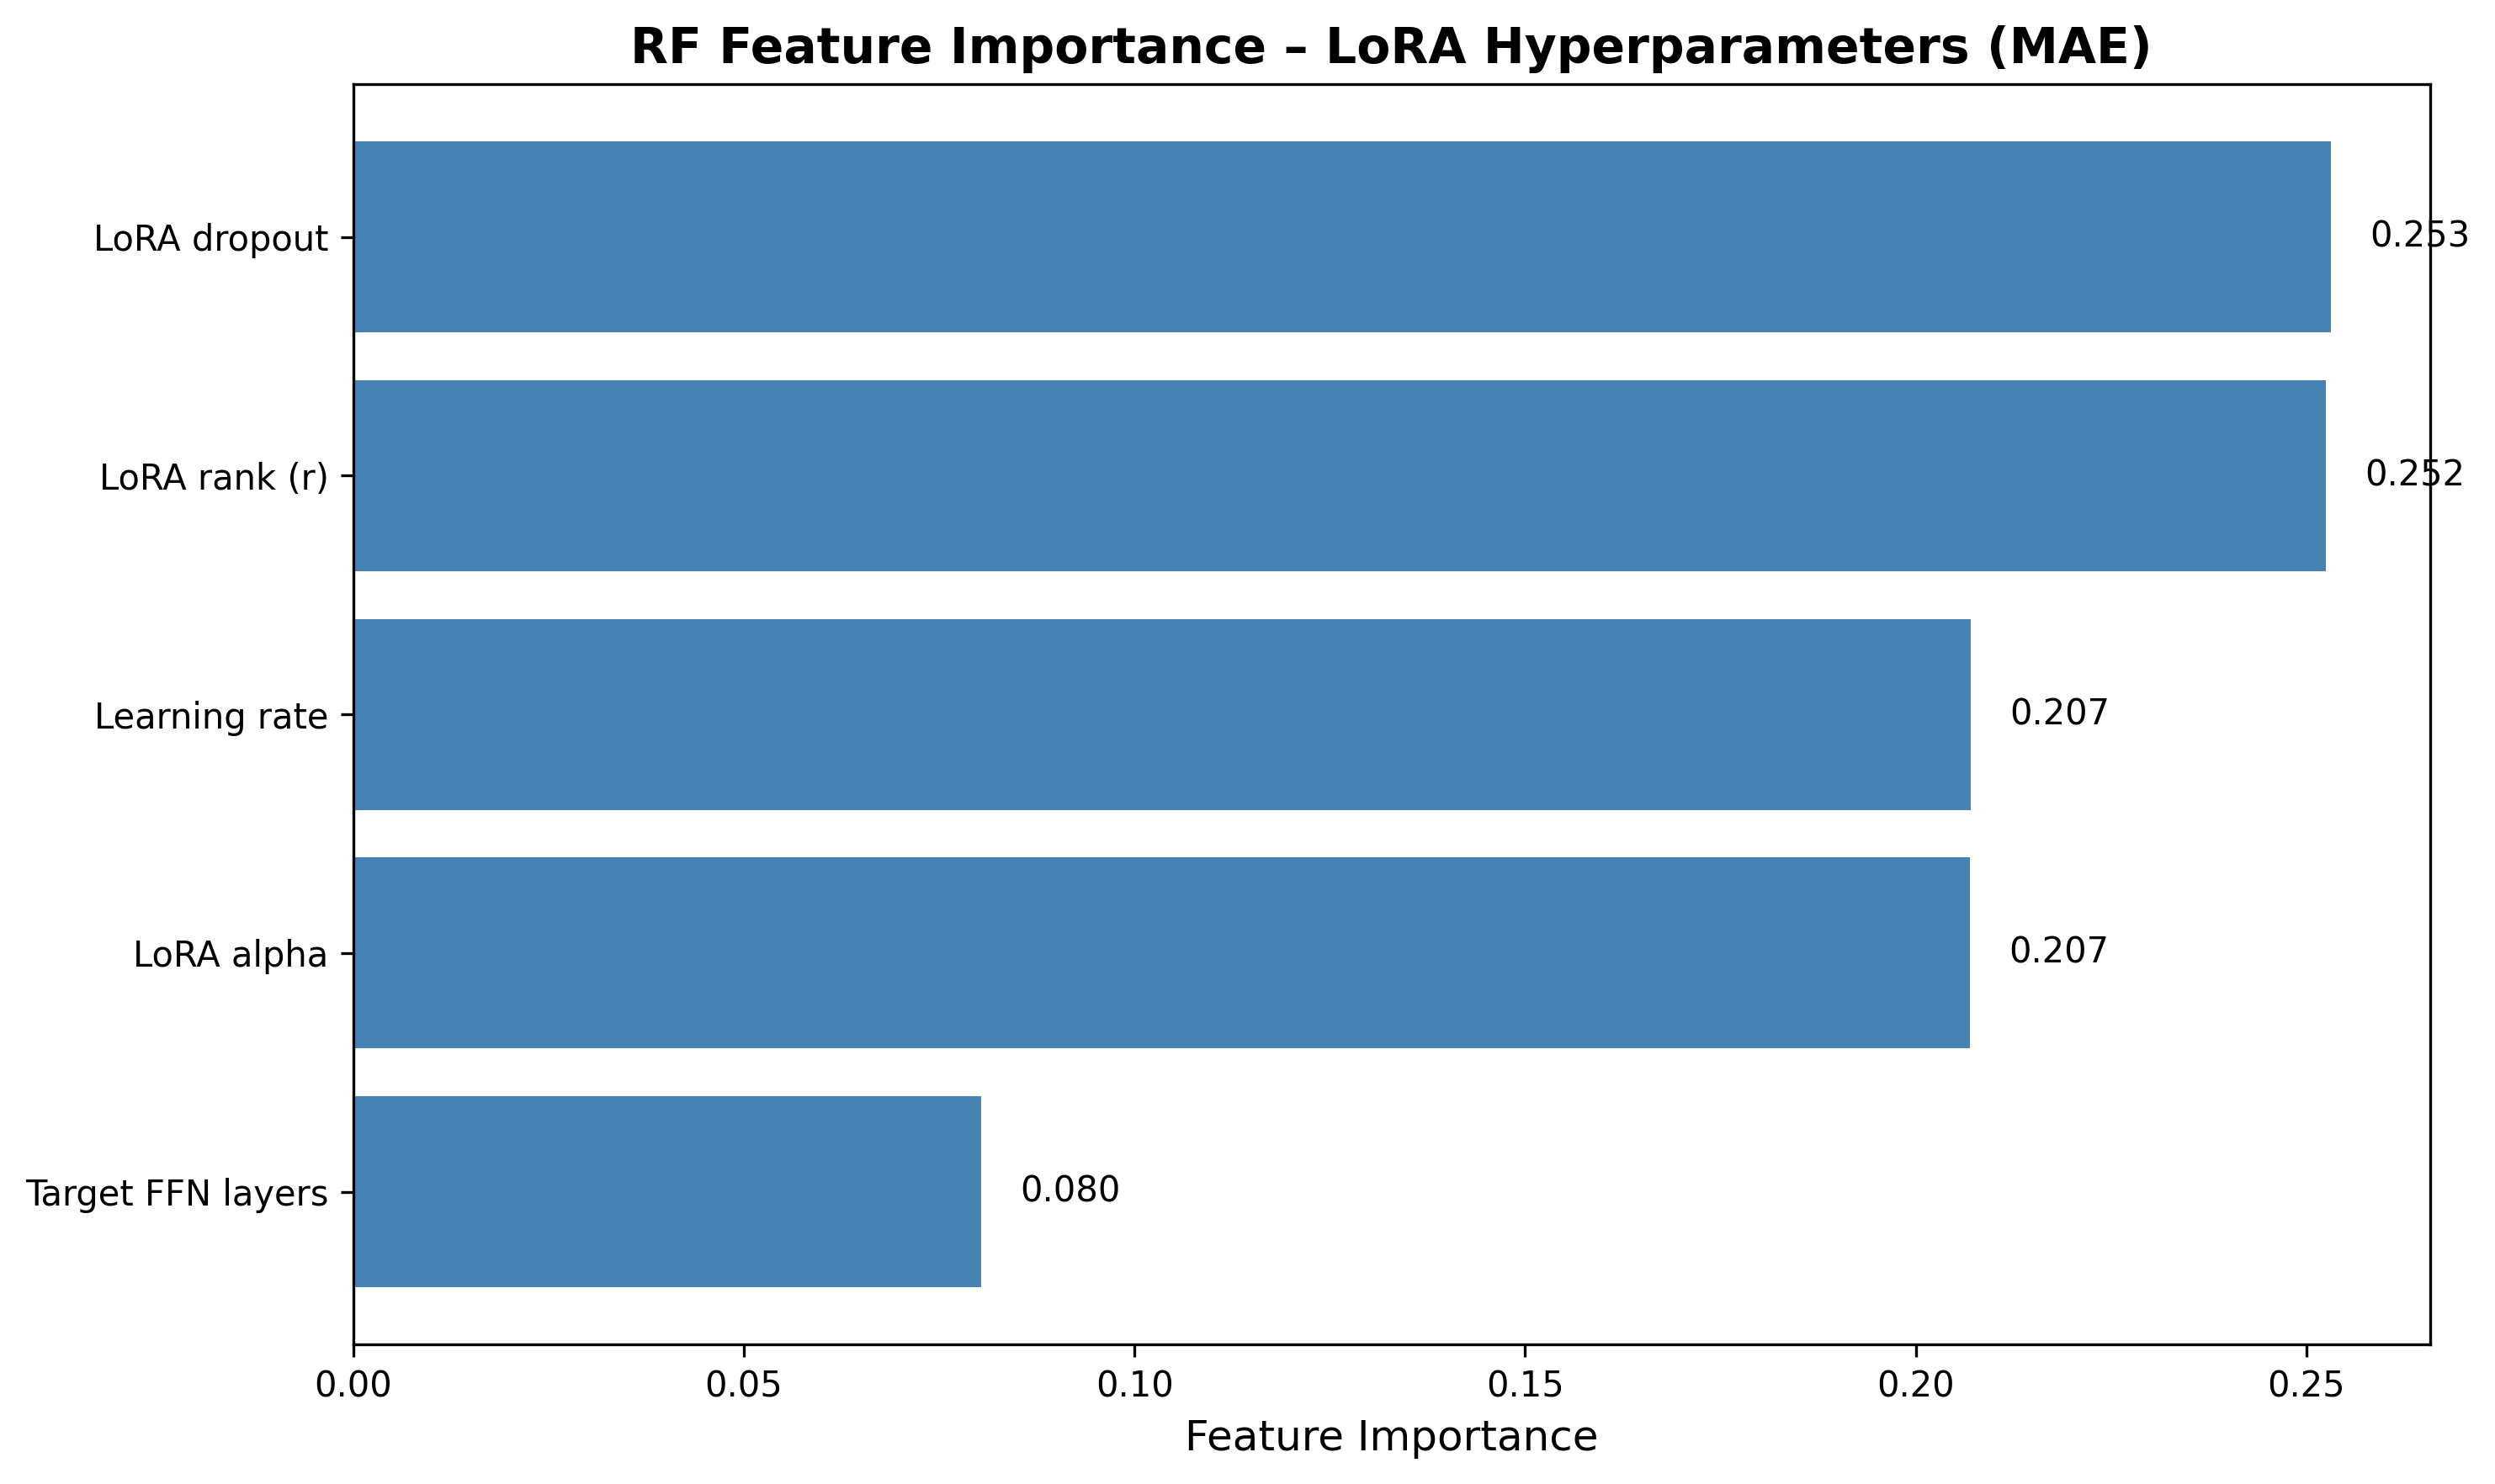


Feature Importance – RANKIC:


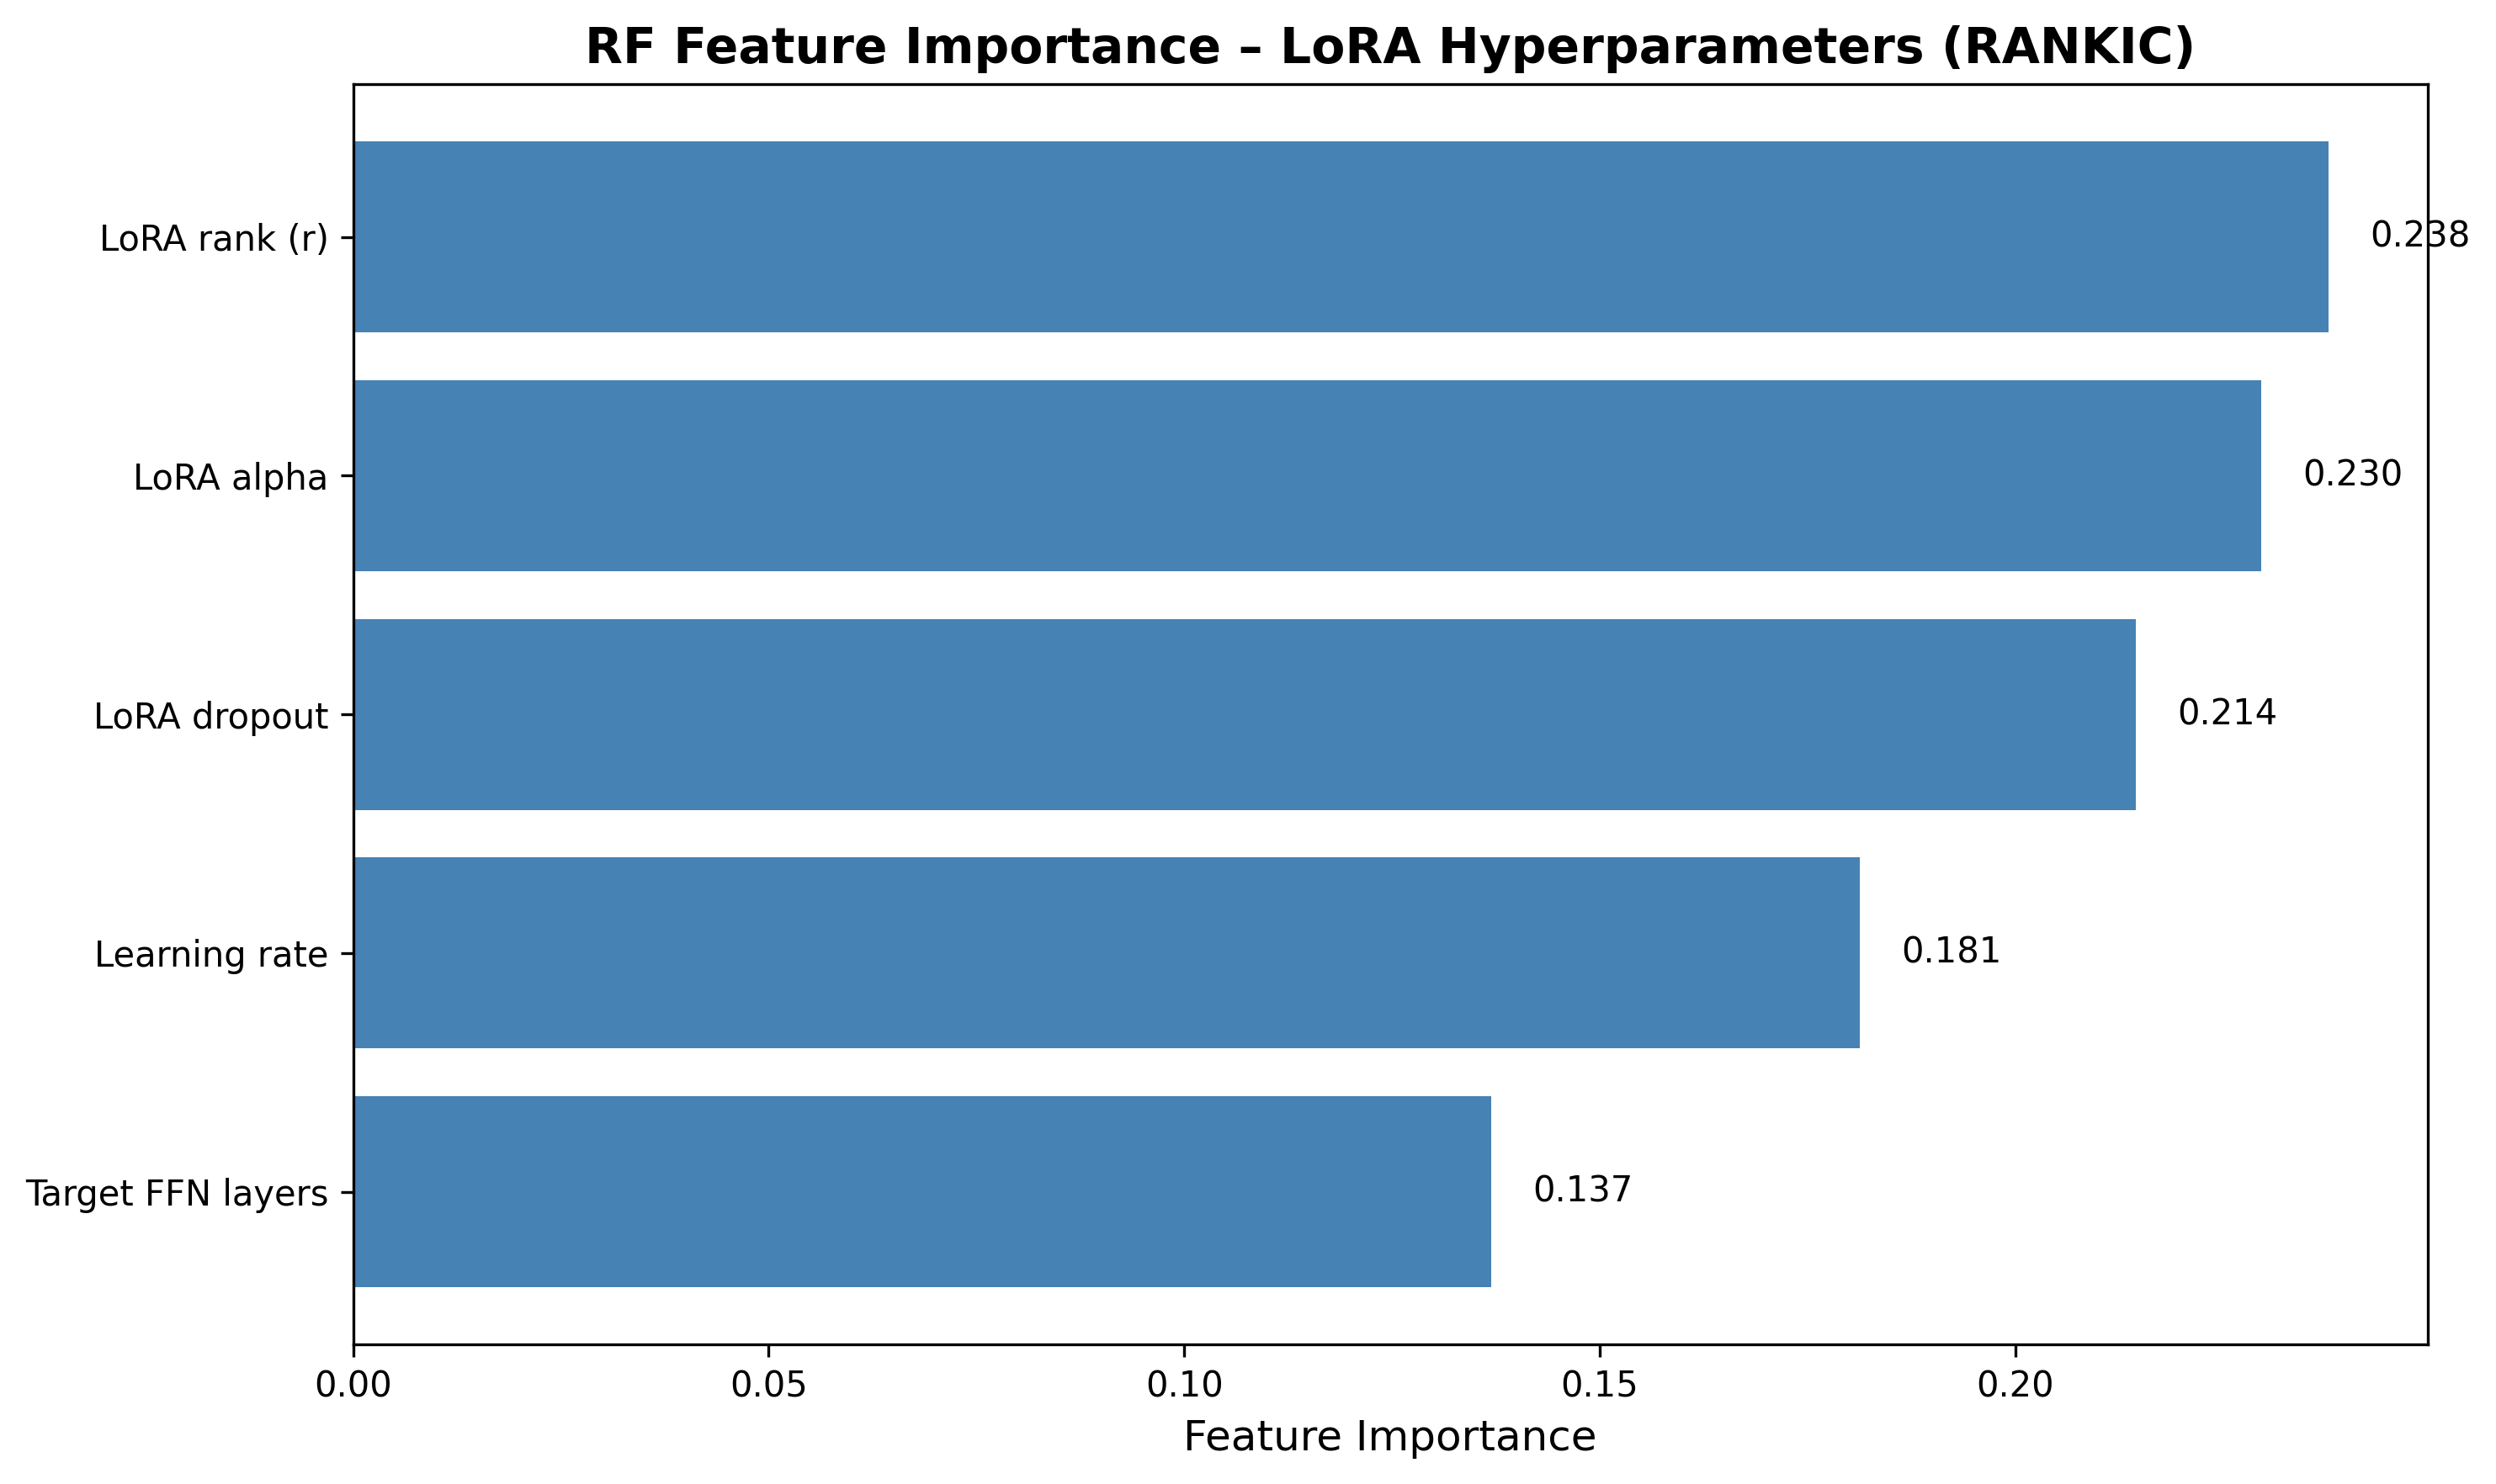

In [11]:
from IPython.display import Image, display
from pathlib import Path

results_dir = Path("03_sensitivity_analysis/lora_parameters/results")

for metric in ['mae', 'rankic']:
    img = results_dir / f"rf_importance_lora_{metric}.png"
    if img.exists():
        print(f"\nFeature Importance – {metric.upper()}:")
        display(Image(str(img)))

## Download Results

In [12]:
from google.colab import files
import zipfile
from pathlib import Path

zip_name = "lora_sensitivity_results.zip"
results_dir = Path("03_sensitivity_analysis/lora_parameters/results")

with zipfile.ZipFile(zip_name, 'w') as zf:
    for f in results_dir.iterdir():
        if f.suffix in ('.csv', '.png'):
            zf.write(f, arcname=f.name)

files.download(zip_name)
print(f"Downloaded: {zip_name}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: lora_sensitivity_results.zip
